# Deep Deterministic Policy Gradient

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from ddpg.ddpg_hw import ddpg_trainer
from IPython.display import HTML, clear_output, display
import tensorflow as tf
#print(tf.__version__)
#import keras
#print(keras.__version__)

2025-07-10 11:49:07.174430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752140947.199763  347681 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752140947.216016  347681 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752140947.236593  347681 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752140947.236632  347681 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752140947.236634  347681 computation_placer.cc:177] computation placer alr

In [2]:
# pendulum parameters
pendulum_model_name = 'rail'
# rail pendulum
if pendulum_model_name == 'rail':
    mass = 0.06 
    length = 0.1
    damping = 0.0004
    torque_limit = 0.02 # changed from 0.02
    coulomb_fric = 0.0
# dfki pendulum
elif pendulum_model_name == 'dfki':  
    mass = 0.57288
    length = 0.5
    damping = 0.15
    torque_limit = 1.5
    coulomb_fric = 0.02
else:
    raise Exception(f"Pendulum model {pendulum_model_name} not implemented")


inertia = mass*length**2

gravity = 9.81


# environment parameters
dt = 0.05 # changed from 0.01
real_pendulum = True
integrator = "runge_kutta"
max_steps = 200 # changed from 200
reward_type = "combined_reward"
target = [np.pi, 0]
target_epsilon = [0.1, 0.1] # changed from 0.05
random_init = "False" # "False", "everywhere", "start_vicinity"

# training parameters
n_episodes = 60
batch_size = 64
validate_every = 10
validation_reps = 10
validation_limit = 0 
train_every_steps = 1
state_representation = 3
replay_buffer_size = 50_000 # changed from 50_000
episode_type = "hw"

#actor = tf.keras.models.load_model("log_data/ddpg_training/actor.keras")
#actor.compile(optimizer="adam", loss="mse")
#critic = tf.keras.models.load_model("log_data/ddpg_training/critic.keras")
#critic.compile(optimizer="adam", loss="mse")
actor = None  # use default agent
critic = None  # use default critic
discount = 0.99
actor_lr = 0.0005
critic_lr = 0.001 
tau = 0.005 

In [3]:
save_dir = "log_data/ddpg_training"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

print(f"Using pendulum model from {pendulum_model_name}.")


trainer = ddpg_trainer(batch_size=batch_size,
                       validate_every=validate_every,
                       validation_reps=validation_reps,
                       train_every_steps=train_every_steps)

trainer.init_pendulum(mass=mass,
                      length=length,
                      inertia=inertia,
                      damping=damping,
                      coulomb_friction=coulomb_fric,
                      gravity=gravity,
                      torque_limit=torque_limit)

trainer.init_environment(dt=dt,
                         integrator=integrator,
                         max_steps=max_steps,
                         reward_type=reward_type,
                         state_representation=state_representation,
                         validation_limit=validation_limit,
                         target=target,
                         state_target_epsilon=target_epsilon,
                         random_init=random_init,)

trainer.init_agent(replay_buffer_size=replay_buffer_size,
                   actor=actor,
                   critic=critic,
                   discount=discount,
                   actor_lr=actor_lr,
                   critic_lr=critic_lr,
                   tau=tau)

rewards, actor_losses, critic_losses = trainer.train(n_episodes=n_episodes,
                                                     verbose=True, episode_type=episode_type)


trainer.save(save_dir)

Using pendulum model from rail.


/home/jupyter-davidrui/.local/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
E0000 00:00:1752135789.325375  341478 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1752135789.342527  341478 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

...

 Total params: 83,361 (325.63 KB)

 Trainable params: 83,361 (325.63 KB)

 Non-trainable params: 0 (0.00 B)

None
Your experiment hash key is: 908822469163295232
Your livestreaming URL is:  http://cloudpendulum.m2.chalmers.se:5080/live/viewer.jsp?host=cloudpendulum.m2.chalmers.se&stream=camera_141
Initial position requested: -2.7548178484106565
Initial position:  -2.325515031814575
Control Loop Started!
Control Loop Ended!076348005329
Going back to the zero config!
Experiment Finished!
Episode: 0, Steps: 199, Reward: -1581.55, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [-0.05330583  0.47643596], Success: False
Your experiment hash key is: 1660120193669693184
Your livestreaming URL is:  http://cloudpendulum.m2.chalmers.se:5080/live/viewer.jsp?host=cloudpendulum.m2.chalmers.se&stream=camera_904
Initial position requested: 2.0574706088559704
Initial position:  1.5381993055343628
Control Loop Started!
Control Loop Ended!895745122785
Going back to the zero config!
Experiment Finished!
Episode: 1, Steps: 199, Reward: -1766.26, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [0.00115049 0.13552

KeyboardInterrupt: 

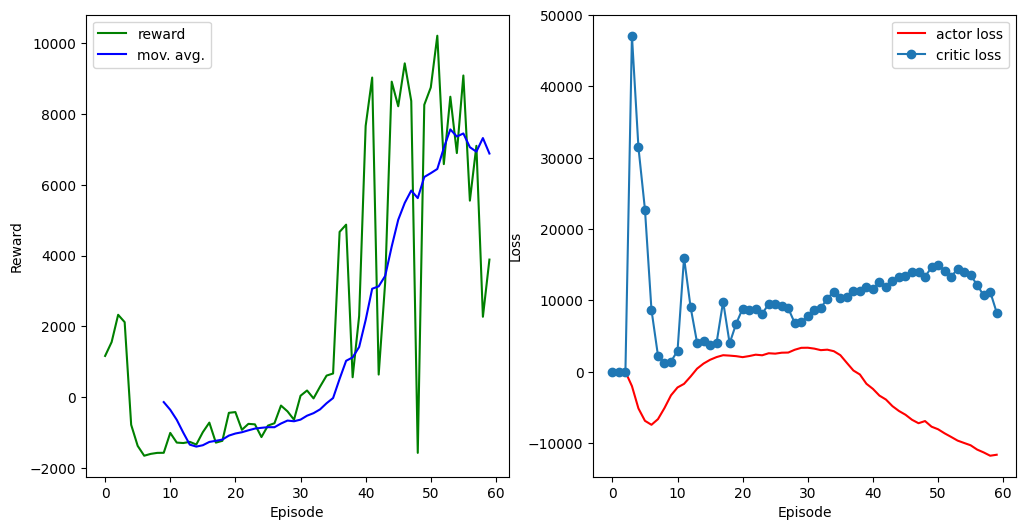

In [4]:
# plotting
MA_WINDOW = 10
ma_rewards = np.convolve(rewards, np.ones(MA_WINDOW)/MA_WINDOW, mode='valid')
episodes = np.arange(0, len(rewards))
ma_episodes = np.arange(len(rewards)-len(ma_rewards), len(rewards))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Reward, per episode and moving average
ax[0].plot(episodes, rewards, '-g', label='reward')
ax[0].plot(ma_episodes, ma_rewards, '-b', label='mov. avg.')
ax[0].set_xlabel('Episode')
ax[0].set_ylabel('Reward')
ax[0].legend()

ax[1].plot(actor_losses, '-r', label='actor loss')
ax[1].plot(critic_losses, '-o', label='critic loss')
ax[1].set_xlabel('Episode')
ax[1].set_ylabel('Loss')
ax[1].legend()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pendulum_plant.pendulum_plantzeroRPC import PendulumPlant
from pendulum_plant.simulation import Simulator
from ddpg.ddpg_controller import ddpg_controller


# Simulation using trained model

I0000 00:00:1752140949.620347  347681 gpu_device.cc:2383] Ignoring visible gpu device (device: 0, name: NVIDIA GeForce GT 640, pci bus id: 0000:41:00.0, compute capability: 3.0) with Cuda compute capability 3.0. The minimum required Cuda capability is 3.5.


Final torque: -0.001400931621901691


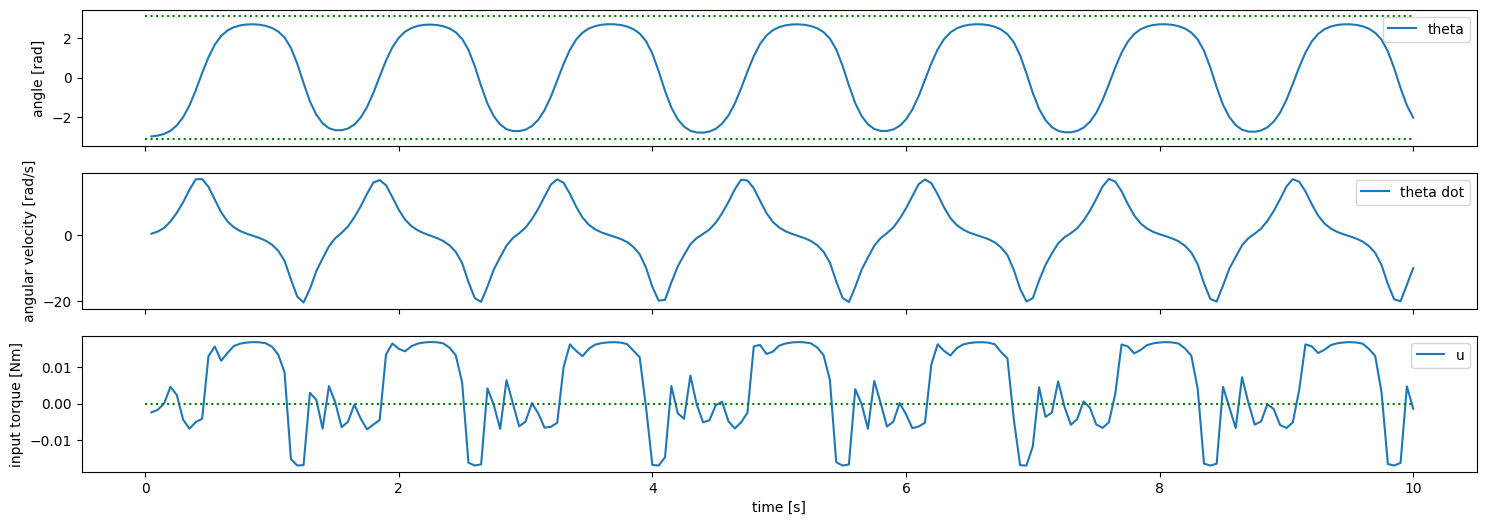

In [4]:


#mass = 0.2
#length = 0.1
#damping = 0.0004 #chagned from 0.0004
#torque_limit = 0.02
#coulomb_fric = 0.0
#mass = 0.06
#length = 0.1
#damping = 0.0004
#gravity = 9.81
#coulomb_fric = 0.02
#torque_limit = 0.01
#inertia = mass*length*length


#dt = 0.05
t_final = 10.0
animate = False
pendulum = PendulumPlant(mass=mass,
                         length=length,
                         damping=damping,
                         gravity=gravity,
                         #coulomb_fric=coulomb_fric,
                         inertia=inertia,
                         torque_limit=torque_limit)


#model_path = "log_data/ddpg_training/actor.keras"
model_path = "log_data/ddpg_training-090725/actor.keras"
#model_path = "log_data/ddpg_training_250804_best_yet/actor"
#model_path = "log_data/ddpg_training_250804_trained40ep/actor"

controller = ddpg_controller(model_path=model_path,
                             torque_limit=torque_limit,
                             state_representation=3)


sim = Simulator(plant=pendulum)

if animate:
  T, X, U = sim.simulate_and_animate(t0=0.0,
                                    x0=[-0.1, -0.0],
                                    tf=t_final,
                                    dt=dt,
                                    controller=controller,
                                    integrator="runge_kutta",
                                    save_video=True,
                                    video_name="video.mp4")
  video_html = HTML("""
  <video width="640" height="480" controls>
    <source src="video.mp4" type="video/mp4">
  </video>
  """)
  display(video_html)
  plt.close()
else:
    
  T, X, U = sim.simulate(t0=0.0,
                        x0=[-3.0, 0.0],
                        tf=t_final,
                        dt=dt,
                        controller=controller,
                        integrator="runge_kutta", push_torque=0)

fig, ax = plt.subplots(3, 1, figsize=(18, 6), sharex="all")
print(f"Final torque: {U[-1]}")
ax[0].plot(T, np.asarray(X).T[0], label="theta")
#theta_wrapped = (np.asarray(X).T[0] + np.pi) % (2 * np.pi) - np.pi
#ax[0].plot(T, theta_wrapped, label="theta")
ax[0].hlines(y=[-np.pi, np.pi], xmin=0, xmax = t_final, linestyles = ':', colors='g')
ax[0].set_ylabel("angle [rad]")
ax[0].legend(loc="best")
ax[1].plot(T, np.asarray(X).T[1], label="theta dot")
ax[1].set_ylabel("angular velocity [rad/s]")
ax[1].legend(loc="best")
ax[2].plot(T, np.asarray(U).flatten(), label="u")
ax[2].set_xlabel("time [s]")
ax[2].set_ylabel("input torque [Nm]")
ax[2].hlines(y=0, xmin=0, xmax=t_final, linestyles = ':', colors='g')
ax[2].legend(loc="best")
plt.show()



Initial positions requested: 0
Control Loop Started!
Control loop is too slow!4083
Control frequency: 15.265503699632767 Hz
Desired frequency: 40.0 Hz

Control Loop Ended!619666121547
Going back to the zero config!
Experiment Finished!


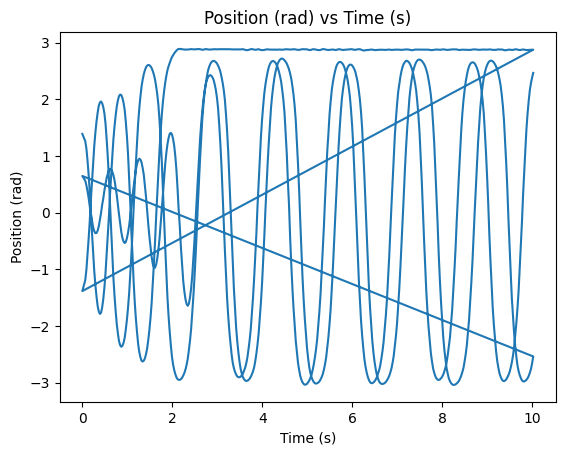

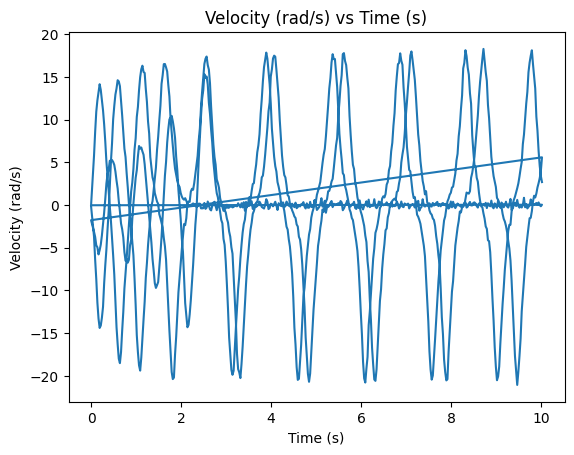

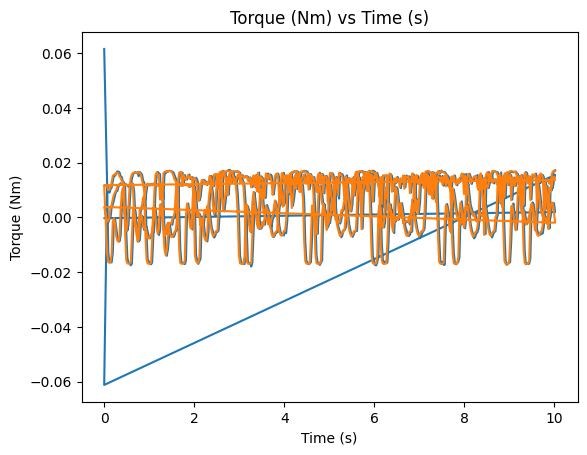

In [5]:
tf = 10 # Final time (s)
dt = 0.025 # Time step (s)
controller2 = ddpg_controller(model_path=model_path,
                             torque_limit=torque_limit,
                             state_representation=3)
controller3 = ddpg_controller(model_path=model_path,
                             torque_limit=torque_limit,
                             state_representation=3)
Treal_es, Xreal_es, Ureal_es, Ureal_es_des, vod_filepath = pendulum.run_on_hardware_hash_parallel(tf, dt, controllers=[controller, controller2, controller3]) 

# Measured Position
plt.figure
plt.plot(Treal_es, np.asarray(Xreal_es).T[0])
plt.xlabel("Time (s)") 
plt.ylabel("Position (rad)")
plt.title("Position (rad) vs Time (s)")
plt.show()

# Measured Velocity
plt.figure
plt.plot(Treal_es, np.asarray(Xreal_es).T[1])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (rad/s)")
plt.title("Velocity (rad/s) vs Time (s)")
plt.show()

# Measured Torque
plt.figure
plt.plot(Treal_es, Ureal_es)
plt.plot(Treal_es, Ureal_es_des)
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Torque (Nm) vs Time (s)")
plt.show()

# Export the data to csv file
measured_csv_data_es = np.array([Treal_es, np.asarray(Xreal_es).T[0], np.asarray(Xreal_es).T[1],Ureal_es]).T
np.savetxt("es_measured_data_es.csv", measured_csv_data_es, delimiter=',', header="time,pos,vel,tau", comments="")

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_angle_vs_angvel_heatmap(replay_buffer, bins=50):
    """
    Plots a 2D heatmap of (angle, angular velocity) visit frequency from replay buffer.

    Parameters
    ----------
    replay_buffer: ReplayBuffer
        The buffer containing 3D state vectors: [x, y, angular_speed].

    bins: int
        Number of bins in each dimension for the 2D histogram.
    """
    if replay_buffer.num_states < 3:
        raise ValueError("State vector must contain at least [x, y, angular_speed]")

    # Extract stored states
    num_records = min(replay_buffer.size, replay_buffer.buffer_capacity)
    states = replay_buffer.state_buffer[:num_records]

    x = states[:, 0]
    y = states[:, 1]
    angular_speed = states[:, 2]

    # Compute angle in radians
    angles = np.arctan2(y, x)

    # Create 2D histogram of (angle, angular velocity)
    heatmap, xedges, yedges = np.histogram2d(
        angles, angular_speed, bins=bins
    )

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    c = ax.imshow(
        np.log1p(heatmap.T),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='plasma',
        aspect='auto'
    )
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("Angle (rad)")
    ax.set_ylabel("Angular Velocity")
    ax.set_title("Heatmap: Angle vs. Angular Velocity(log scale, color bar does not match)")
    plt.tight_layout()
    plt.show()

plot_angle_vs_angvel_heatmap(trainer.replay_buffer)


NameError: name 'trainer' is not defined

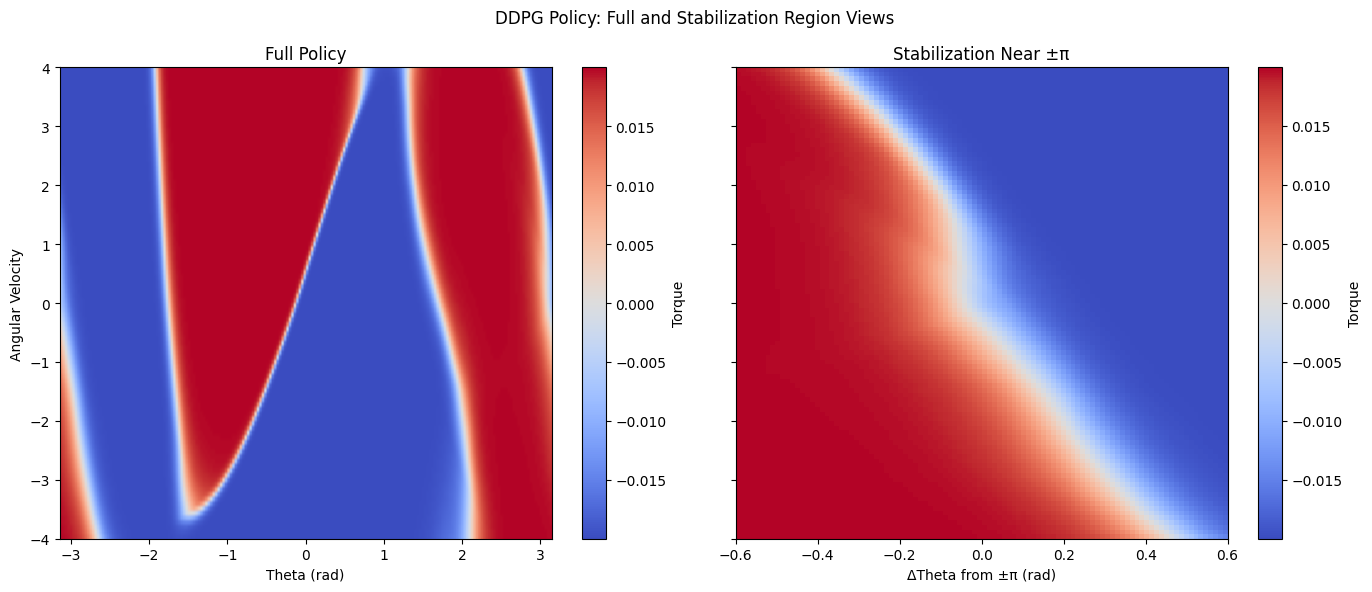

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_policy_with_stabilization_view(controller, 
                                             theta_range=(-np.pi, np.pi), 
                                             vel_range=(-8, 8), 
                                             stab_range=0.6,
                                             bins=200,
                                             zoom_bins=100):
    """
    Plots two heatmaps:
    1. Full (theta, velocity) policy
    2. Zoomed view around stabilization point ±π, shown as deviation from upright

    Parameters
    ----------
    controller : ddpg_controller
        The DDPG controller.
    theta_range : tuple
        Range for theta in full plot.
    vel_range : tuple
        Range for velocity in both plots.
    stab_range : float
        Maximum deviation (in radians) from the upright position (π or -π).
    bins : int
        Resolution for full plot.
    zoom_bins : int
        Resolution for zoom plot.
    """
    def compute_actions(theta_vals, vel_vals):
        actions = np.zeros((len(vel_vals), len(theta_vals)))
        for i, th in enumerate(theta_vals):
            for j, vel in enumerate(vel_vals):
                _, _, action = controller.get_control_output(meas_pos=th, meas_vel=vel)
                actions[j, i] = action
        return actions

    # === Full policy ===
    thetas = np.linspace(*theta_range, bins)
    vels = np.linspace(*vel_range, bins)
    full_actions = compute_actions(thetas, vels)

    # === Stabilization view around ±π ===
    delta_zoom = np.linspace(-stab_range, stab_range, zoom_bins)
    vels_zoom = np.linspace(-4, 4, zoom_bins)

    # Map delta_theta to wrapped angles near ±π
    theta_zoom = np.pi + delta_zoom  # around π



    actions_zoom = np.zeros((zoom_bins, zoom_bins))
    for i, dt in enumerate(delta_zoom):
        for j, vel in enumerate(vels_zoom):
            _, _, a_left = controller.get_control_output(meas_pos=-np.pi + dt, meas_vel=vel)
            actions_zoom[j, i] = a_left

    # === Plotting ===
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Full plot
    im1 = axs[0].imshow(full_actions, extent=[*theta_range, *vel_range],
                        origin='lower', aspect='auto', cmap='coolwarm')
    axs[0].set_title("Full Policy")
    axs[0].set_xlabel("Theta (rad)")
    axs[0].set_ylabel("Angular Velocity")
    fig.colorbar(im1, ax=axs[0], label='Torque')

    # Stabilization plot
    x_extent = [-stab_range, stab_range]
    im2 = axs[1].imshow(actions_zoom, extent=[x_extent[0], x_extent[1], -4, 4],
                        origin='lower', aspect='auto', cmap='coolwarm')
    axs[1].set_title("Stabilization Near ±π")
    axs[1].set_xlabel("ΔTheta from ±π (rad)")
    fig.colorbar(im2, ax=axs[1], label='Torque')

    plt.suptitle("DDPG Policy: Full and Stabilization Region Views")
    plt.tight_layout()
    plt.show()
visualize_policy_with_stabilization_view(controller)

In [1]:
import time
import numpy as np
from pendulum_plant.gym_environment_hw import SimplePendulumEnv

def run_test_episode():
    env = SimplePendulumEnv(
        dt=0.025,  # 100Hz
        max_steps=200,
        reward_type="combined_reward",
        state_representation=3,
        torque_limit=0.002,
        random_init="everywhere",
        dt_step_scaling = 0.8
    )

    obs = env.reset()
    print("Reset obs: ", obs)
    total_reward = 0

    for step in range(env.max_steps):
        action = env.action_space.sample()
        obs, reward, done, info = env.step(action)
        total_reward += reward
        print(f"Step {step}, Reward: {reward:.3f}, Done: {done}")

        if done:
            break

    print("Episode finished. Total reward:", total_reward)

if __name__ == "__main__":
    run_test_episode()


/home/jupyter-davidrui/.local/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Control Loop Started!
Reset obs:  [ 0.76910335 -0.63912445  0.07890255]
Step 0, Reward: -10.000, Done: False
Step 1, Reward: -10.000, Done: False
Step 2, Reward: -10.000, Done: False
Step 3, Reward: -10.000, Done: False
Step 4, Reward: -10.000, Done: False
Step 5, Reward: -10.000, Done: False
Step 6, Reward: -10.000, Done: False
Step 7, Reward: -10.000, Done: False
Step 8, Reward: -10.000, Done: False
Step 9, Reward: -10.000, Done: False
Step 10, Reward: -10.000, Done: False
Step 11, Reward: -10.000, Done: False
Step 12, Reward: -10.000, Done: False
Step 13, Reward: -10.000, Done: False
Step 14, Reward: -10.000, Done: False
Step 15, Reward: -10.000, Done: False
Step 16, Reward: -10.000, Done: False
Step 17, Reward: -10.000, Done: False
Step 18, Reward: -10.000, Done: False
Step 19, Reward: -10.000, Done: False
Step 20, Reward: -10.000, Done: False
Step 21, Reward: -10.000, Done: False
Step 22, Reward: -10.000, Done: False
Step 23, Reward: -10.000, Done: False
Step 24, Reward: -10.000, 

In [4]:
from stable_baselines3.common.vec_env import SubprocVecEnv
import time
import numpy as np
from pendulum_plant.gym_environment_hw import SimplePendulumEnv

# Factory function for each environment
def make_env(env_id):
    def _init():
        env = SimplePendulumEnv(
            dt=0.025,
            max_steps=200,
            reward_type="open_ai_gym",
            state_representation=3,
            torque_limit=0.004,
            random_init="everywhere",
            dt_step_scaling=0.8
        )
        print(f"[ENV {env_id}] initialized.")
        return env
    return _init

# Create list of env builders
num_envs = 3
env_fns = [make_env(i) for i in range(num_envs)]

# Create the vectorized environment
envs = SubprocVecEnv(env_fns)

# Reset all environments
obs = envs.reset()

total_rewards = np.zeros(num_envs)
done_flags = [False] * num_envs
max_steps = 100

for step in range(max_steps):
    actions = [envs.action_space.sample() for _ in range(num_envs)]
    actions = np.array(actions)
    
    obs, rewards, dones, infos = envs.step(actions)
    total_rewards += rewards
    
    print(f"[Step {step}] Rewards: {rewards}, Done: {dones}")
    
    if all(dones):
        print("All envs done.")
        break

print(f"Total rewards per env: {total_rewards}")
envs.close()


2025-07-10 11:42:47.151375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752140567.172898  346663 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752140567.179690  346663 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752140567.197264  346663 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752140567.197289  346663 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752140567.197292  346663 computation_placer.cc:177] computation placer alr

[Step 0] Rewards: [-3.35047515 -8.30516194 -8.74267611], Done: [False False False]
[Step 1] Rewards: [-5.97458649 -8.36481433 -9.03234879], Done: [False False False]
[Step 2] Rewards: [-9.16429574 -8.60645175 -9.57012626], Done: [False False False]
[Step 3] Rewards: [-12.91312632  -8.63323595  -9.77673879], Done: [False False False]
[Step 4] Rewards: [-18.77162321  -8.76846903 -10.09902309], Done: [False False False]
[Step 5] Rewards: [-23.04063411  -8.84640505 -10.25640864], Done: [False False False]
[Step 6] Rewards: [-28.70410146  -8.99140793  -9.62925051], Done: [False False False]
[Step 7] Rewards: [-27.67647634  -9.13339198  -9.35170277], Done: [False False False]
[Step 8] Rewards: [-24.10005774  -9.24805506  -9.07992235], Done: [False False False]
[Step 9] Rewards: [-18.11098214  -9.40745149  -8.92284954], Done: [False False False]
[Step 10] Rewards: [-12.14330235  -9.61805312  -8.86327343], Done: [False False False]
[Step 11] Rewards: [-7.51954186 -9.72390987 -8.91000293], Done